# Optional Transfer Layer: Mapping Party Positions to Democratic Connection Priorities

This notebook extends the main ESS11 Germany analysis by mapping standardized party positions to the democratic connection dimensions identified in the core project.

The purpose is exploratory and communicative.

The main ESS analysis showed that democratic connection is most strongly associated with:

- political efficacy
- social trust
- voting participation
- economic security
- institutional responsiveness
- democratic satisfaction and party trust

This transfer layer asks:

**Which democratic connection priorities are addressed by the policy positions of major German parties?**

The analysis does not rank parties normatively.  
It does not claim that one party “solves” democratic disconnection.  
Instead, it maps party positions to the analytical dimensions identified in the ESS analysis.

The goal is to connect survey-based democratic trust findings with a cautious, evidence-informed political interpretation.

## 0. Analytical Purpose and Methodological Scope

This notebook is not part of the core statistical ESS analysis.

It is an exploratory transfer layer that connects the empirical findings to party-political positioning.

The approach is based on three principles:

1. **Transparency**  
   All coding decisions should be visible and documented.

2. **Comparability**  
   Party positions should be compared using the same set of issues.

3. **Caution**  
   The results should be interpreted as an issue-alignment map, not as a causal or normative party ranking.

The analysis therefore avoids claims such as:

> Party X is best for democracy.

Instead, it uses cautious language:

> Party X has more visible positions related to this democratic connection dimension in the selected issue set.

### Methodological note on the Wahl-O-Mat transfer layer

The Wahl-O-Mat layer is used as an exploratory issue-position mapping, not as a full party-programme analysis.

The dataset is useful because all parties respond to the same set of standardized statements. This makes party positions comparable within the selected issue set.

However, the Wahl-O-Mat does not represent the full ideological, strategic or programmatic profile of a party. It reflects selected issues from the 2025 election context and should therefore not be interpreted as a complete assessment of each party's democratic orientation.

This limitation is especially important for dimensions such as political efficacy. In the Wahl-O-Mat issue set, political efficacy is captured only narrowly, mainly through direct-democratic participation issues such as referendums. Therefore, this dimension is interpreted as direct participation / political voice rather than as the full ESS concept of political efficacy.

The results should be read as cautious issue-alignment patterns:

Party X has more visible agreement with selected issues related to this democratic connection dimension.

They should not be read as normative rankings or as evidence that a party causally strengthens democratic trust.

## 1. Import Libraries and Define Project Paths

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 250)

PROJECT_ROOT = Path("..")
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_APP = PROJECT_ROOT / "data" / "app"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
DATA_APP.mkdir(parents=True, exist_ok=True)

print("Paths ready.")

Paths ready.


## 2. Data Logic

The preferred input is a structured Wahl-O-Mat 2025 party-position dataset.

The ideal dataset should contain:

- issue or thesis text
- party name
- party position
- optional explanation text

Typical party positions can be recoded as:

- support / agree
- neutral
- oppose / disagree

For this project, the party positions are not analyzed as voter advice.  
They are used as a standardized issue-position dataset to map parties against democratic connection dimensions.

## 3. Load Wahl-O-Mat 2025 Party Position Dataset

This step loads the Wahl-O-Mat 2025 party position dataset from the raw data folder.

The dataset is used as a standardized issue-position source. It allows the analysis to compare how selected German parties position themselves on the same set of political statements.

In this project, the data is not used as voter advice. It is used as an exploratory transfer layer to connect party positions with the democratic connection priorities identified in the ESS11 Germany analysis.

In [5]:
# 3. Load Wahl-O-Mat 2025 party position dataset

wahlomat_path = DATA_RAW / "wahlomat_2025_party_positions.xlsx"

print("File exists:", wahlomat_path.exists())
print("File path:", wahlomat_path)

wahlomat_df = pd.read_excel(wahlomat_path)

print("Dataset loaded successfully.")
print("Shape:", wahlomat_df.shape)

wahlomat_df.head()

File exists: True
File path: ../data/raw/wahlomat_2025_party_positions.xlsx
Dataset loaded successfully.
Shape: (1064, 8)


,Partei: Nr.,Partei: Kurzbezeichnung,Partei: Name,These: Nr.,These: Titel,These: These,Position: Position,Position: Begründung
0,1,SPD,Sozialdemokratische Partei Deutschlands,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,"Die SPD bekennt sich klar zur diplomatischen, militärischen, finanziellen und humanitären Unterstützung der Ukraine im Kampf gegen den völkerrechtswidrigen russischen Angriffskrieg – so lange wie nötig. Die Ukraine muss mögliche Verhandlungen auf..."
1,2,CDU / CSU,Christlich Demokratische Union Deutschlands / Christlich-Soziale Union in Bayern e.V.,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,"Unser Ziel ist Frieden in Europa. Die Ukraine verteidigt auch uns, denn fällt die Ukraine, droht ein russischer Angriff auf weitere Länder. Daher unterstützen wir die Ukraine mit diplomatischen, finanziellen und humanitären Mitteln sowie mit Waff..."
2,3,GRÜNE,BÜNDNIS 90/DIE GRÜNEN,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,"Millionen Ukrainer*innen verteidigen Tag für Tag ihr Leben, ihre Freiheit und den Frieden in Europa gegen die brutale Aggression von Putins Russland. Dabei stehen wir fest an ihrer Seite - mit diplomatischer, finanzieller, humanitärer und militär..."
3,4,FDP,Freie Demokratische Partei,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,Unsere Unterstützung für die Ukraine darf nicht an Geld oder Waffenlieferungen scheitern. Denn die Ukraine verteidigt auch unsere Freiheit. Daher fordern wir u.a. die Lieferung von Taurus und weiterer Waffensysteme an die Ukraine. Wir setzen uns ...
4,5,AfD,Alternative für Deutschland,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme nicht zu,"Wir fordern von allen Kriegsparteien eine Einstellung der Kampfhandlungen und die Aufnahme von Friedensgesprächen ohne Vorbedingungen. Die Alternative für Deutschland versteht sich als Partei, in der Diplomatie und friedliche Konfliktbewältigung ..."


## 4. Verify Project Paths and Raw Data Availability

This step checks whether the notebook is running from the expected folder and whether the raw data folder contains the required input files.

This is mainly a reproducibility check. It helps avoid path errors when the notebook is run from a different working directory.

In [ ]:
# 4. Verify project paths and raw data availability

print("Current working directory:")
print(Path.cwd())

print("\nFiles/folders one level up:")
for p in Path("..").iterdir():
    print(p)

print("\nFiles in ../data/raw if folder exists:")
raw_path = DATA_RAW
print("raw folder exists:", raw_path.exists())

if raw_path.exists():
    for p in raw_path.iterdir():
        print(p.name)

Current working directory:
/Users/kainaegle/Desktop/Capstone 2026/capstone-democratic-connection-ess11/notebooks

Files/folders one level up:
../.DS_Store
../app
../LICENSE
../requirements.txt
../docs
../README.md
../visualizations
../.gitignore
../.git
../data
../notebooks
../reports

Files in ../data/raw if folder exists:
raw folder exists: True
ESS11e04_1.sav
wahlomat_2025_party_positions.xlsx
ESS11e04_1 codebook.html


## 5. Inspect Wahl-O-Mat Dataset Structure

This step inspects the structure of the Wahl-O-Mat dataset before any transformation.

The goal is to understand:

- how many rows and columns the dataset contains
- how the columns are named
- whether party positions are stored in rows or columns
- whether the file contains explanations in addition to party positions
- whether missing values need to be handled

This inspection is necessary before transforming the dataset into a clean party-position table.

In [6]:
# 5. Inspect Wahl-O-Mat dataset structure

print("Dataset shape:", wahlomat_df.shape)

print("\nColumn names:")
for col in wahlomat_df.columns:
    print(col)

wahlomat_df.head()

Dataset shape: (1064, 8)

Column names:
Partei: Nr.
Partei: Kurzbezeichnung
Partei: Name
These: Nr.
These: Titel
These: These
Position: Position
Position: Begründung


,Partei: Nr.,Partei: Kurzbezeichnung,Partei: Name,These: Nr.,These: Titel,These: These,Position: Position,Position: Begründung
0,1,SPD,Sozialdemokratische Partei Deutschlands,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,"Die SPD bekennt sich klar zur diplomatischen, militärischen, finanziellen und humanitären Unterstützung der Ukraine im Kampf gegen den völkerrechtswidrigen russischen Angriffskrieg – so lange wie nötig. Die Ukraine muss mögliche Verhandlungen auf..."
1,2,CDU / CSU,Christlich Demokratische Union Deutschlands / Christlich-Soziale Union in Bayern e.V.,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,"Unser Ziel ist Frieden in Europa. Die Ukraine verteidigt auch uns, denn fällt die Ukraine, droht ein russischer Angriff auf weitere Länder. Daher unterstützen wir die Ukraine mit diplomatischen, finanziellen und humanitären Mitteln sowie mit Waff..."
2,3,GRÜNE,BÜNDNIS 90/DIE GRÜNEN,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,"Millionen Ukrainer*innen verteidigen Tag für Tag ihr Leben, ihre Freiheit und den Frieden in Europa gegen die brutale Aggression von Putins Russland. Dabei stehen wir fest an ihrer Seite - mit diplomatischer, finanzieller, humanitärer und militär..."
3,4,FDP,Freie Demokratische Partei,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,Unsere Unterstützung für die Ukraine darf nicht an Geld oder Waffenlieferungen scheitern. Denn die Ukraine verteidigt auch unsere Freiheit. Daher fordern wir u.a. die Lieferung von Taurus und weiterer Waffensysteme an die Ukraine. Wir setzen uns ...
4,5,AfD,Alternative für Deutschland,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme nicht zu,"Wir fordern von allen Kriegsparteien eine Einstellung der Kampfhandlungen und die Aufnahme von Friedensgesprächen ohne Vorbedingungen. Die Alternative für Deutschland versteht sich als Partei, in der Diplomatie und friedliche Konfliktbewältigung ..."


In [7]:
# 5.1 Dataset overview

wahlomat_overview = pd.DataFrame({
    "column": wahlomat_df.columns,
    "dtype": [wahlomat_df[col].dtype for col in wahlomat_df.columns],
    "missing_count": [wahlomat_df[col].isna().sum() for col in wahlomat_df.columns],
    "missing_percent": [round(wahlomat_df[col].isna().mean() * 100, 2) for col in wahlomat_df.columns],
    "unique_values": [wahlomat_df[col].nunique(dropna=True) for col in wahlomat_df.columns]
})

wahlomat_overview

,column,dtype,missing_count,missing_percent,unique_values
0,Partei: Nr.,int64,0,0.00,28
1,Partei: Kurzbezeichnung,str,0,0.00,28
2,Partei: Name,str,0,0.00,28
3,These: Nr.,int64,0,0.00,38
4,These: Titel,str,0,0.00,38
5,These: These,str,0,0.00,38
6,Position: Position,str,0,0.00,3
7,Position: Begründung,str,94,8.83,931


## 6. Standardize Column Names

This step renames the Wahl-O-Mat columns into shorter and more analysis-friendly column names.

The original column names are kept conceptually, but the working dataset uses simplified variable names for easier filtering, coding and exporting.

In [9]:
# 6. Standardize column names

wahlomat_clean = wahlomat_df.rename(columns={
    "Partei: Nr.": "party_id",
    "Partei: Kurzbezeichnung": "party_short",
    "Partei: Name": "party_name",
    "These: Nr.": "issue_id",
    "These: Titel": "issue_title",
    "These: These": "issue_text",
    "Position: Position": "position",
    "Position: Begründung": "position_reason"
}).copy()

wahlomat_clean.head()

,party_id,party_short,party_name,issue_id,issue_title,issue_text,position,position_reason
0,1,SPD,Sozialdemokratische Partei Deutschlands,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,"Die SPD bekennt sich klar zur diplomatischen, militärischen, finanziellen und humanitären Unterstützung der Ukraine im Kampf gegen den völkerrechtswidrigen russischen Angriffskrieg – so lange wie nötig. Die Ukraine muss mögliche Verhandlungen auf..."
1,2,CDU / CSU,Christlich Demokratische Union Deutschlands / Christlich-Soziale Union in Bayern e.V.,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,"Unser Ziel ist Frieden in Europa. Die Ukraine verteidigt auch uns, denn fällt die Ukraine, droht ein russischer Angriff auf weitere Länder. Daher unterstützen wir die Ukraine mit diplomatischen, finanziellen und humanitären Mitteln sowie mit Waff..."
2,3,GRÜNE,BÜNDNIS 90/DIE GRÜNEN,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,"Millionen Ukrainer*innen verteidigen Tag für Tag ihr Leben, ihre Freiheit und den Frieden in Europa gegen die brutale Aggression von Putins Russland. Dabei stehen wir fest an ihrer Seite - mit diplomatischer, finanzieller, humanitärer und militär..."
3,4,FDP,Freie Demokratische Partei,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,Unsere Unterstützung für die Ukraine darf nicht an Geld oder Waffenlieferungen scheitern. Denn die Ukraine verteidigt auch unsere Freiheit. Daher fordern wir u.a. die Lieferung von Taurus und weiterer Waffensysteme an die Ukraine. Wir setzen uns ...
4,5,AfD,Alternative für Deutschland,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme nicht zu,"Wir fordern von allen Kriegsparteien eine Einstellung der Kampfhandlungen und die Aufnahme von Friedensgesprächen ohne Vorbedingungen. Die Alternative für Deutschland versteht sich als Partei, in der Diplomatie und friedliche Konfliktbewältigung ..."


In [10]:
wahlomat_clean.info()
wahlomat_clean["party_short"].value_counts().head(30)

<class 'pandas.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   party_id         1064 non-null   int64
 1   party_short      1064 non-null   str  
 2   party_name       1064 non-null   str  
 3   issue_id         1064 non-null   int64
 4   issue_title      1064 non-null   str  
 5   issue_text       1064 non-null   str  
 6   position         1064 non-null   str  
 7   position_reason  970 non-null    str  
dtypes: int64(2), str(6)
memory usage: 590.6 KB


party_short
SPD                                           38
CDU / CSU                                     38
GRÜNE                                         38
FDP                                           38
AfD                                           38
Die Linke                                     38
SSW                                           38
FREIE WÄHLER                                  38
Tierschutzpartei                              38
dieBasis                                      38
Die PARTEI                                    38
Die Gerechtigkeitspartei - Team Todenhöfer    38
PIRATEN                                       38
Volt                                          38
ÖDP                                           38
Verjüngungsforschung                          38
PdH                                           38
Bündnis C                                     38
BP                                            38
MLPD                                          38
MENSCHLI

## 7. Filter Major Bundestag Parties

This step filters the Wahl-O-Mat dataset to major parties represented in the Bundestag context.

The core comparison includes SPD, CDU/CSU, GRÜNE, FDP, AfD and Die Linke. BSW can be included as an additional relevant party depending on presentation scope.

This project does not rank parties normatively. It only compares how visible party positions align with the democratic connection dimensions derived from the ESS analysis.

In [11]:
# 7. Inspect party names

party_overview = (
    wahlomat_clean[["party_id", "party_short", "party_name"]]
    .drop_duplicates()
    .sort_values("party_id")
)

party_overview

,party_id,party_short,party_name
0,1,SPD,Sozialdemokratische Partei Deutschlands
1,2,CDU / CSU,Christlich Demokratische Union Deutschlands / Christlich-Soziale Union in Bayern e.V.
2,3,GRÜNE,BÜNDNIS 90/DIE GRÜNEN
3,4,FDP,Freie Demokratische Partei
4,5,AfD,Alternative für Deutschland
5,6,Die Linke,Die Linke
6,7,SSW,Südschleswigscher Wählerverband
7,8,FREIE WÄHLER,FREIE WÄHLER
8,9,Tierschutzpartei,PARTEI MENSCH UMWELT TIERSCHUTZ
9,10,dieBasis,Basisdemokratische Partei Deutschland


In [13]:
# 7.1 Filter selected parties

selected_parties = [
    "SPD",
    "CDU / CSU",
    "GRÜNE",
    "FDP",
    "AfD",
    "Die Linke",
    "BSW"
]

wahlomat_parties = wahlomat_clean[
    wahlomat_clean["party_short"].isin(selected_parties)
].copy()

print("Filtered dataset shape:", wahlomat_parties.shape)
print("Selected parties:")
print(wahlomat_parties["party_short"].value_counts().sort_index())

wahlomat_parties.head(10)

Filtered dataset shape: (266, 8)
Selected parties:
party_short
AfD          38
BSW          38
CDU / CSU    38
Die Linke    38
FDP          38
GRÜNE        38
SPD          38
Name: count, dtype: int64


,party_id,party_short,party_name,issue_id,issue_title,issue_text,position,position_reason
0,1,SPD,Sozialdemokratische Partei Deutschlands,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,"Die SPD bekennt sich klar zur diplomatischen, militärischen, finanziellen und humanitären Unterstützung der Ukraine im Kampf gegen den völkerrechtswidrigen russischen Angriffskrieg – so lange wie nötig. Die Ukraine muss mögliche Verhandlungen auf..."
1,2,CDU / CSU,Christlich Demokratische Union Deutschlands / Christlich-Soziale Union in Bayern e.V.,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,"Unser Ziel ist Frieden in Europa. Die Ukraine verteidigt auch uns, denn fällt die Ukraine, droht ein russischer Angriff auf weitere Länder. Daher unterstützen wir die Ukraine mit diplomatischen, finanziellen und humanitären Mitteln sowie mit Waff..."
2,3,GRÜNE,BÜNDNIS 90/DIE GRÜNEN,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,"Millionen Ukrainer*innen verteidigen Tag für Tag ihr Leben, ihre Freiheit und den Frieden in Europa gegen die brutale Aggression von Putins Russland. Dabei stehen wir fest an ihrer Seite - mit diplomatischer, finanzieller, humanitärer und militär..."
3,4,FDP,Freie Demokratische Partei,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,Unsere Unterstützung für die Ukraine darf nicht an Geld oder Waffenlieferungen scheitern. Denn die Ukraine verteidigt auch unsere Freiheit. Daher fordern wir u.a. die Lieferung von Taurus und weiterer Waffensysteme an die Ukraine. Wir setzen uns ...
4,5,AfD,Alternative für Deutschland,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme nicht zu,"Wir fordern von allen Kriegsparteien eine Einstellung der Kampfhandlungen und die Aufnahme von Friedensgesprächen ohne Vorbedingungen. Die Alternative für Deutschland versteht sich als Partei, in der Diplomatie und friedliche Konfliktbewältigung ..."
5,6,Die Linke,Die Linke,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme nicht zu,"Militärische Unterstützung hat den Krieg und das Leid nicht beendet. Wir unterstützen diplomatische Initiativen, die Russland und die Ukraine an den Verhandlungstisch bringen. Ziel muss ein Waffenstillstand und ein gerechter Frieden sein."
25,26,BSW,Bündnis Sahra Wagenknecht – Vernunft und Gerechtigkeit,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme nicht zu,NaN
28,1,SPD,Sozialdemokratische Partei Deutschlands,2,Erneuerbare Energien,Der Ausbau erneuerbarer Energien soll weiterhin vom Staat finanziell gefördert werden.,stimme zu,Der konsequente Ausbau von und Umstieg auf erneuerbare Energien sowie die Einbindung von Speichern macht Energieversorgung sicher und dauerhaft bezahlbar. Wir wollen mit Augenmaß fördern: Gerade bisher weniger beachtete Erneuerbare wie etwa die G...
29,2,CDU / CSU,Christlich Demokratische Union Deutschlands / Christlich-Soziale Union in Bayern e.V.,2,Erneuerbare Energien,Der Ausbau erneuerbarer Energien soll weiterhin vom Staat finanziell gefördert werden.,stimme zu,"Wir bringen alle Kapazitäten ans Netz, die klimafreundlich und systemdienlich sind, angefangen bei einem zielgerichteten weiteren Ausbau der Erneuerbaren Energien. Ein besonderes Augenmerk legen wir auf den integrierten und grenzüberschreitenden ..."
30,3,GRÜNE,BÜNDNIS 90/DIE GRÜNEN,2,Erneuerbare Energien,Der Ausbau erneuerbarer Energien soll weiterhin vom Staat finanziell gefördert werden.,stimme zu,"Günstiger Strom aus erneuerbaren Energien wie Wind, Sonne, Wasserkraft, Geothermie sowie naturverträgliche Bioenergie sichern unseren Wohlstand. Wir halten Kurs mit dem erreichten Rekord-Ausbautempo. Dazu werden wir auch in Zukunft dezentrale Erz..."


In [14]:
# 8. Recode party positions

position_map = {
    "stimme zu": 1,
    "neutral": 0,
    "stimme nicht zu": -1
}

wahlomat_parties["position_score"] = wahlomat_parties["position"].map(position_map)

print("Position recoding check:")
print(wahlomat_parties[["position", "position_score"]].drop_duplicates())

wahlomat_parties.head()

Position recoding check:
            position  position_score
0          stimme zu               1
4    stimme nicht zu              -1
193          neutral               0


,party_id,party_short,party_name,issue_id,issue_title,issue_text,position,position_reason,position_score
0,1,SPD,Sozialdemokratische Partei Deutschlands,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,"Die SPD bekennt sich klar zur diplomatischen, militärischen, finanziellen und humanitären Unterstützung der Ukraine im Kampf gegen den völkerrechtswidrigen russischen Angriffskrieg – so lange wie nötig. Die Ukraine muss mögliche Verhandlungen auf...",1
1,2,CDU / CSU,Christlich Demokratische Union Deutschlands / Christlich-Soziale Union in Bayern e.V.,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,"Unser Ziel ist Frieden in Europa. Die Ukraine verteidigt auch uns, denn fällt die Ukraine, droht ein russischer Angriff auf weitere Länder. Daher unterstützen wir die Ukraine mit diplomatischen, finanziellen und humanitären Mitteln sowie mit Waff...",1
2,3,GRÜNE,BÜNDNIS 90/DIE GRÜNEN,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,"Millionen Ukrainer*innen verteidigen Tag für Tag ihr Leben, ihre Freiheit und den Frieden in Europa gegen die brutale Aggression von Putins Russland. Dabei stehen wir fest an ihrer Seite - mit diplomatischer, finanzieller, humanitärer und militär...",1
3,4,FDP,Freie Demokratische Partei,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme zu,Unsere Unterstützung für die Ukraine darf nicht an Geld oder Waffenlieferungen scheitern. Denn die Ukraine verteidigt auch unsere Freiheit. Daher fordern wir u.a. die Lieferung von Taurus und weiterer Waffensysteme an die Ukraine. Wir setzen uns ...,1
4,5,AfD,Alternative für Deutschland,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,stimme nicht zu,"Wir fordern von allen Kriegsparteien eine Einstellung der Kampfhandlungen und die Aufnahme von Friedensgesprächen ohne Vorbedingungen. Die Alternative für Deutschland versteht sich als Partei, in der Diplomatie und friedliche Konfliktbewältigung ...",-1


In [15]:
wahlomat_parties["position_score"].isna().sum()

np.int64(0)

In [16]:
wahlomat_parties.groupby("party_short")["position_score"].value_counts().unstack(fill_value=0)

position_score,-1,0,1
party_short,,,
AfD,17,5,16
BSW,14,8,16
CDU / CSU,16,3,19
Die Linke,18,2,18
FDP,20,4,14
GRÜNE,17,1,20
SPD,15,3,20


## 9. Inspect Wahl-O-Mat Issues

This step lists all Wahl-O-Mat issues included in the selected party-position dataset.

Each issue is represented by an issue number, a short title and the full statement text.

The issue list is the basis for the next coding step, where each issue will be mapped to one or more democratic connection dimensions.

This is necessary because the party-position dataset does not directly measure democratic trust. Instead, it provides policy positions that can be cautiously linked to the democratic connection priorities identified in the ESS analysis.

In [17]:
# 9. Inspect Wahl-O-Mat issues

issue_overview = (
    wahlomat_parties[["issue_id", "issue_title", "issue_text"]]
    .drop_duplicates()
    .sort_values("issue_id")
    .reset_index(drop=True)
)

print("Number of unique issues:", issue_overview.shape[0])

issue_overview

Number of unique issues: 38


,issue_id,issue_title,issue_text
0,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.
1,2,Erneuerbare Energien,Der Ausbau erneuerbarer Energien soll weiterhin vom Staat finanziell gefördert werden.
2,3,Streichung des Bürgergelds,"Das Bürgergeld soll denjenigen gestrichen werden, die wiederholt Stellenangebote ablehnen."
3,4,Tempolimit auf Autobahnen,Auf allen Autobahnen soll ein generelles Tempolimit gelten.
4,5,Abweisung Asylsuchender,"Asylsuchende, die über einen anderen EU-Staat eingereist sind, sollen an den deutschen Grenzen abgewiesen werden."
5,6,Begrenzung der Mietpreise,Bei Neuvermietungen sollen die Mietpreise weiterhin gesetzlich begrenzt werden.
6,7,Automatisierte Gesichtserkennung,An Bahnhöfen soll die Bundespolizei Software zur automatisierten Gesichtserkennung einsetzen dürfen.
7,8,Energieintensive Unternehmen,Energieintensive Unternehmen sollen vom Staat einen finanziellen Ausgleich für ihre Stromkosten erhalten.
8,9,Rente nach 40 Beitragsjahren,Alle Beschäftigten sollen bereits nach 40 Beitragsjahren ohne Abschläge in Rente gehen können.
9,10,Grundgesetz,Im einleitenden Satz des Grundgesetzes soll weiterhin die Formulierung „Verantwortung vor Gott“ stehen.


## 9.1 Export Issue Overview for Coding

This step exports the Wahl-O-Mat issue overview as a CSV file.

The exported file can be used as a transparent coding template for assigning each issue to democratic connection dimensions.

Keeping this file makes the coding process more reproducible and easier to inspect.

In [18]:
# 9.1 Export issue overview for coding

issue_overview_path = DATA_PROCESSED / "wahlomat_2025_issue_overview.csv"

issue_overview.to_csv(issue_overview_path, index=False)

print("Issue overview exported to:", issue_overview_path)

Issue overview exported to: ../data/processed/wahlomat_2025_issue_overview.csv


## 10. Define Democratic Connection Coding Scheme

This step defines the coding scheme used to map Wahl-O-Mat issues to the democratic connection dimensions identified in the ESS analysis.

The coding dimensions are derived from the core project findings:

- political efficacy
- social trust
- economic security
- institutional responsiveness
- democratic institutions
- participation and civic inclusion

Each Wahl-O-Mat issue can be assigned to one primary democratic connection dimension.

The coding is interpretative and should therefore be transparent. It does not claim that a party position directly causes higher or lower democratic trust. Instead, it identifies whether a party position is visibly related to one of the analytical dimensions.

In [19]:
# 10. Define democratic connection coding scheme

connection_dimensions = {
    "political_efficacy": {
        "label": "Political efficacy",
        "description": "Issues related to political voice, influence, participation rights and citizens' ability to shape politics."
    },
    "social_trust": {
        "label": "Social trust",
        "description": "Issues related to social cohesion, inclusion, anti-discrimination, solidarity and trust between groups."
    },
    "economic_security": {
        "label": "Economic security",
        "description": "Issues related to income, work, welfare, affordability, redistribution and material security."
    },
    "institutional_responsiveness": {
        "label": "Institutional responsiveness",
        "description": "Issues related to state capacity, service delivery, administrative responsiveness and government effectiveness."
    },
    "democratic_institutions": {
        "label": "Democratic institutions",
        "description": "Issues related to rule of law, constitutional order, democratic norms, security and institutional trust."
    },
    "participation_civic_inclusion": {
        "label": "Participation and civic inclusion",
        "description": "Issues related to voting, citizenship, civic participation, access and inclusion in democratic life."
    },
    "not_directly_related": {
        "label": "Not directly related",
        "description": "Issues that are policy-relevant but not clearly linked to the democratic connection dimensions in this project."
    }
}

coding_scheme_df = pd.DataFrame([
    {
        "dimension": key,
        "label": value["label"],
        "description": value["description"]
    }
    for key, value in connection_dimensions.items()
])

coding_scheme_df

,dimension,label,description
0,political_efficacy,Political efficacy,"Issues related to political voice, influence, participation rights and citizens' ability to shape politics."
1,social_trust,Social trust,"Issues related to social cohesion, inclusion, anti-discrimination, solidarity and trust between groups."
2,economic_security,Economic security,"Issues related to income, work, welfare, affordability, redistribution and material security."
3,institutional_responsiveness,Institutional responsiveness,"Issues related to state capacity, service delivery, administrative responsiveness and government effectiveness."
4,democratic_institutions,Democratic institutions,"Issues related to rule of law, constitutional order, democratic norms, security and institutional trust."
5,participation_civic_inclusion,Participation and civic inclusion,"Issues related to voting, citizenship, civic participation, access and inclusion in democratic life."
6,not_directly_related,Not directly related,Issues that are policy-relevant but not clearly linked to the democratic connection dimensions in this project.


## 10.1 Export Coding Scheme

This step exports the democratic connection coding scheme.

The coding scheme documents how Wahl-O-Mat issues will be linked to the ESS-based democratic connection priorities.

In [20]:
# 10.1 Export coding scheme

coding_scheme_path = DATA_PROCESSED / "democratic_connection_coding_scheme.csv"

coding_scheme_df.to_csv(coding_scheme_path, index=False)

print("Coding scheme exported to:", coding_scheme_path)

Coding scheme exported to: ../data/processed/democratic_connection_coding_scheme.csv


## 11. Code Wahl-O-Mat Issues into Democratic Connection Dimensions

This step manually maps each Wahl-O-Mat issue to one primary democratic connection dimension.

The coding is based on the conceptual framework of the ESS analysis:

- political efficacy
- social trust
- economic security
- institutional responsiveness
- democratic institutions
- participation and civic inclusion
- not directly related

The coding is interpretative and transparent. It does not claim that a party position directly causes democratic trust. Instead, it identifies whether a policy issue is visibly connected to one of the democratic connection priorities found in the ESS analysis.

Some issues are not directly related to the democratic connection framework. These are kept in the dataset but marked as not directly related.

In [21]:
# 11. Code Wahl-O-Mat issues into democratic connection dimensions

issue_dimension_map = {
    1: "democratic_institutions",          # Ukraine support: international order / security / democratic institutions
    2: "institutional_responsiveness",     # renewable energy: state capacity / future-oriented policy delivery
    3: "economic_security",               # citizen income / welfare conditionality
    4: "not_directly_related",            # speed limit
    5: "social_trust",                    # asylum / social cohesion / inclusion
    6: "economic_security",               # rent regulation / affordability
    7: "democratic_institutions",          # surveillance / security / civil liberties
    8: "economic_security",               # support for energy-intensive companies / industrial jobs
    9: "economic_security",               # pension security
    10: "democratic_institutions",         # constitutional symbolism
    11: "institutional_responsiveness",    # skilled migration / labour market capacity
    12: "institutional_responsiveness",    # energy system / state capacity
    13: "economic_security",              # taxation / redistribution
    14: "institutional_responsiveness",    # federal education governance
    15: "democratic_institutions",         # arms exports / international responsibility
    16: "economic_security",              # health insurance / social protection
    17: "social_trust",                   # gender equality / inclusion
    18: "not_directly_related",           # organic farming
    19: "democratic_institutions",         # anti-extremism / democratic resilience
    20: "democratic_institutions",         # human rights / supply chain accountability
    21: "economic_security",              # BAföG / education access / material security
    22: "institutional_responsiveness",    # fiscal capacity / state investment ability
    23: "participation_civic_inclusion",   # asylum seekers' labour access / inclusion
    24: "institutional_responsiveness",    # climate neutrality / long-term state capacity
    25: "economic_security",              # working time / labour conditions
    26: "democratic_institutions",         # reproductive rights / legal framework
    27: "democratic_institutions",         # euro / European integration / institutional order
    28: "institutional_responsiveness",    # transport infrastructure priorities
    29: "participation_civic_inclusion",   # volunteering / civic contribution
    30: "economic_security",              # property tax burden / housing costs
    31: "participation_civic_inclusion",   # strike rights / collective participation
    32: "political_efficacy",             # referendums / direct citizen influence
    33: "democratic_institutions",         # criminal responsibility / rule of law
    34: "not_directly_related",           # tariffs on Chinese electric cars
    35: "participation_civic_inclusion",   # dual citizenship / civic inclusion
    36: "participation_civic_inclusion",   # social service year / civic participation
    37: "institutional_responsiveness",    # heating / climate and energy transition
    38: "economic_security"               # minimum wage
}

issue_relevance_map = {
    1: "indirect",
    2: "indirect",
    3: "direct",
    4: "low",
    5: "direct",
    6: "direct",
    7: "direct",
    8: "direct",
    9: "direct",
    10: "indirect",
    11: "indirect",
    12: "indirect",
    13: "direct",
    14: "direct",
    15: "indirect",
    16: "direct",
    17: "direct",
    18: "low",
    19: "direct",
    20: "direct",
    21: "direct",
    22: "indirect",
    23: "direct",
    24: "indirect",
    25: "direct",
    26: "indirect",
    27: "indirect",
    28: "indirect",
    29: "direct",
    30: "direct",
    31: "direct",
    32: "direct",
    33: "indirect",
    34: "low",
    35: "direct",
    36: "direct",
    37: "indirect",
    38: "direct"
}

issue_coding = issue_overview.copy()

issue_coding["connection_dimension"] = issue_coding["issue_id"].map(issue_dimension_map)
issue_coding["connection_relevance"] = issue_coding["issue_id"].map(issue_relevance_map)

issue_coding.head()

,issue_id,issue_title,issue_text,connection_dimension,connection_relevance
0,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,democratic_institutions,indirect
1,2,Erneuerbare Energien,Der Ausbau erneuerbarer Energien soll weiterhin vom Staat finanziell gefördert werden.,institutional_responsiveness,indirect
2,3,Streichung des Bürgergelds,"Das Bürgergeld soll denjenigen gestrichen werden, die wiederholt Stellenangebote ablehnen.",economic_security,direct
3,4,Tempolimit auf Autobahnen,Auf allen Autobahnen soll ein generelles Tempolimit gelten.,not_directly_related,low
4,5,Abweisung Asylsuchender,"Asylsuchende, die über einen anderen EU-Staat eingereist sind, sollen an den deutschen Grenzen abgewiesen werden.",social_trust,direct


## 11.1 Add Readable Dimension Labels

This step adds readable labels to the coded democratic connection dimensions.

These labels make the output easier to use in tables, visualizations and the Streamlit app.

In [22]:
# 11.1 Add readable dimension labels

dimension_label_map = {
    "political_efficacy": "Political efficacy",
    "social_trust": "Social trust",
    "economic_security": "Economic security",
    "institutional_responsiveness": "Institutional responsiveness",
    "democratic_institutions": "Democratic institutions",
    "participation_civic_inclusion": "Participation and civic inclusion",
    "not_directly_related": "Not directly related"
}

issue_coding["connection_dimension_label"] = issue_coding["connection_dimension"].map(dimension_label_map)

issue_coding = issue_coding[
    [
        "issue_id",
        "issue_title",
        "issue_text",
        "connection_dimension",
        "connection_dimension_label",
        "connection_relevance"
    ]
]

issue_coding

,issue_id,issue_title,issue_text,connection_dimension,connection_dimension_label,connection_relevance
0,1,Unterstützung der Ukraine,Deutschland soll die Ukraine weiterhin militärisch unterstützen.,democratic_institutions,Democratic institutions,indirect
1,2,Erneuerbare Energien,Der Ausbau erneuerbarer Energien soll weiterhin vom Staat finanziell gefördert werden.,institutional_responsiveness,Institutional responsiveness,indirect
2,3,Streichung des Bürgergelds,"Das Bürgergeld soll denjenigen gestrichen werden, die wiederholt Stellenangebote ablehnen.",economic_security,Economic security,direct
3,4,Tempolimit auf Autobahnen,Auf allen Autobahnen soll ein generelles Tempolimit gelten.,not_directly_related,Not directly related,low
4,5,Abweisung Asylsuchender,"Asylsuchende, die über einen anderen EU-Staat eingereist sind, sollen an den deutschen Grenzen abgewiesen werden.",social_trust,Social trust,direct
5,6,Begrenzung der Mietpreise,Bei Neuvermietungen sollen die Mietpreise weiterhin gesetzlich begrenzt werden.,economic_security,Economic security,direct
6,7,Automatisierte Gesichtserkennung,An Bahnhöfen soll die Bundespolizei Software zur automatisierten Gesichtserkennung einsetzen dürfen.,democratic_institutions,Democratic institutions,direct
7,8,Energieintensive Unternehmen,Energieintensive Unternehmen sollen vom Staat einen finanziellen Ausgleich für ihre Stromkosten erhalten.,economic_security,Economic security,direct
8,9,Rente nach 40 Beitragsjahren,Alle Beschäftigten sollen bereits nach 40 Beitragsjahren ohne Abschläge in Rente gehen können.,economic_security,Economic security,direct
9,10,Grundgesetz,Im einleitenden Satz des Grundgesetzes soll weiterhin die Formulierung „Verantwortung vor Gott“ stehen.,democratic_institutions,Democratic institutions,indirect


## 11.2 Check Coding Distribution

This step checks how many Wahl-O-Mat issues were assigned to each democratic connection dimension.

This is a plausibility check. It helps assess whether the coding scheme is balanced enough for exploratory interpretation.

In [23]:
# 11.2 Check coding distribution

dimension_distribution = (
    issue_coding
    .groupby(["connection_dimension", "connection_dimension_label", "connection_relevance"])
    .size()
    .reset_index(name="n_issues")
    .sort_values(["connection_dimension_label", "connection_relevance"])
)

dimension_distribution

,connection_dimension,connection_dimension_label,connection_relevance,n_issues
0,democratic_institutions,Democratic institutions,direct,3
1,democratic_institutions,Democratic institutions,indirect,6
2,economic_security,Economic security,direct,10
3,institutional_responsiveness,Institutional responsiveness,direct,1
4,institutional_responsiveness,Institutional responsiveness,indirect,7
5,not_directly_related,Not directly related,low,3
6,participation_civic_inclusion,Participation and civic inclusion,direct,5
7,political_efficacy,Political efficacy,direct,1
8,social_trust,Social trust,direct,2


In [24]:
# 11.2b Summary by dimension

dimension_summary = (
    issue_coding
    .groupby(["connection_dimension", "connection_dimension_label"])
    .agg(
        n_issues=("issue_id", "count"),
        direct_issues=("connection_relevance", lambda x: (x == "direct").sum()),
        indirect_issues=("connection_relevance", lambda x: (x == "indirect").sum()),
        low_relevance_issues=("connection_relevance", lambda x: (x == "low").sum())
    )
    .reset_index()
    .sort_values("n_issues", ascending=False)
)

dimension_summary

,connection_dimension,connection_dimension_label,n_issues,direct_issues,indirect_issues,low_relevance_issues
1,economic_security,Economic security,10,10,0,0
0,democratic_institutions,Democratic institutions,9,3,6,0
2,institutional_responsiveness,Institutional responsiveness,8,1,7,0
4,participation_civic_inclusion,Participation and civic inclusion,5,5,0,0
3,not_directly_related,Not directly related,3,0,0,3
6,social_trust,Social trust,2,2,0,0
5,political_efficacy,Political efficacy,1,1,0,0


## 11.3 Export Issue Coding Table

This step exports the coded Wahl-O-Mat issue table.

The exported file documents the transparent mapping between Wahl-O-Mat issues and democratic connection dimensions.
It can be used later for party-position aggregation and for the Streamlit app.

In [25]:
# 11.3 Export issue coding table

issue_coding_path = DATA_PROCESSED / "wahlomat_2025_issue_democratic_connection_coding.csv"

issue_coding.to_csv(issue_coding_path, index=False)

print("Issue coding exported to:", issue_coding_path)

Issue coding exported to: ../data/processed/wahlomat_2025_issue_democratic_connection_coding.csv


## 11.4 Refine Coding Labels for Methodological Caution

This step refines the dimension labels used in the Wahl-O-Mat transfer layer.

The core ESS analysis identifies political efficacy as a broad and important predictor of democratic connection. However, the Wahl-O-Mat issue set captures this dimension only narrowly, mainly through direct-democratic participation issues such as referendums.

Therefore, the label used in the transfer layer is adjusted from political efficacy to direct participation / political voice.

This makes the interpretation more cautious and avoids overstating what the Wahl-O-Mat data can measure.

In [26]:
# 11.4 Refine coding labels for methodological caution

refined_dimension_label_map = {
    "political_efficacy": "Direct participation / political voice",
    "social_trust": "Social trust and cohesion",
    "economic_security": "Economic security",
    "institutional_responsiveness": "Institutional responsiveness",
    "democratic_institutions": "Democratic institutions and rule of law",
    "participation_civic_inclusion": "Participation and civic inclusion",
    "not_directly_related": "Not directly related"
}

issue_coding["connection_dimension_label_refined"] = (
    issue_coding["connection_dimension"].map(refined_dimension_label_map)
)

issue_coding[
    [
        "issue_id",
        "issue_title",
        "connection_dimension",
        "connection_dimension_label_refined",
        "connection_relevance"
    ]
]

,issue_id,issue_title,connection_dimension,connection_dimension_label_refined,connection_relevance
0,1,Unterstützung der Ukraine,democratic_institutions,Democratic institutions and rule of law,indirect
1,2,Erneuerbare Energien,institutional_responsiveness,Institutional responsiveness,indirect
2,3,Streichung des Bürgergelds,economic_security,Economic security,direct
3,4,Tempolimit auf Autobahnen,not_directly_related,Not directly related,low
4,5,Abweisung Asylsuchender,social_trust,Social trust and cohesion,direct
5,6,Begrenzung der Mietpreise,economic_security,Economic security,direct
6,7,Automatisierte Gesichtserkennung,democratic_institutions,Democratic institutions and rule of law,direct
7,8,Energieintensive Unternehmen,economic_security,Economic security,direct
8,9,Rente nach 40 Beitragsjahren,economic_security,Economic security,direct
9,10,Grundgesetz,democratic_institutions,Democratic institutions and rule of law,indirect


## 11.5 Methodological Note on the Wahl-O-Mat Transfer Layer

The Wahl-O-Mat transfer layer is used as an exploratory issue-position mapping, not as a full party-programme analysis.

The dataset is useful because all parties respond to the same set of standardized statements. This makes party positions comparable within the selected issue set.

However, the Wahl-O-Mat does not represent the full ideological, strategic or programmatic profile of a party. It reflects selected issues from the 2025 election context and should therefore not be interpreted as a complete assessment of each party's democratic orientation.

This limitation is especially important for dimensions such as political efficacy. In the Wahl-O-Mat issue set, political efficacy is captured only narrowly, mainly through direct-democratic participation issues such as referendums. Therefore, this dimension is interpreted as direct participation / political voice rather than as the full ESS concept of political efficacy.

The results should be read as cautious issue-alignment patterns:

Party X has more visible agreement with selected issues related to this democratic connection dimension.

They should not be read as normative rankings or as evidence that a party causally strengthens democratic trust.

## 11.6 Export Refined Issue Coding Table

This step exports the refined issue coding table.

The exported file documents how each Wahl-O-Mat issue is mapped to a democratic connection dimension and includes the more cautious refined labels used for communication.

In [27]:
# 11.6 Export refined issue coding table

refined_issue_coding_path = (
    DATA_PROCESSED / "wahlomat_2025_issue_democratic_connection_coding_refined.csv"
)

issue_coding.to_csv(refined_issue_coding_path, index=False)

print("Refined issue coding exported to:", refined_issue_coding_path)

Refined issue coding exported to: ../data/processed/wahlomat_2025_issue_democratic_connection_coding_refined.csv


## 12. Merge Party Positions with Democratic Connection Coding

This step merges the selected Wahl-O-Mat party positions with the democratic connection issue coding.

The result is a party-position dataset where each party position is linked to a democratic connection dimension.

This enables aggregation by party and dimension.

In [28]:
# 12. Merge party positions with issue coding

party_connection_positions = wahlomat_parties.merge(
    issue_coding[
        [
            "issue_id",
            "connection_dimension",
            "connection_dimension_label_refined",
            "connection_relevance"
        ]
    ],
    on="issue_id",
    how="left"
)

print("Merged dataset shape:", party_connection_positions.shape)

party_connection_positions[
    [
        "party_short",
        "issue_id",
        "issue_title",
        "position",
        "position_score",
        "connection_dimension_label_refined",
        "connection_relevance"
    ]
].head()

Merged dataset shape: (266, 12)


,party_short,issue_id,issue_title,position,position_score,connection_dimension_label_refined,connection_relevance
0,SPD,1,Unterstützung der Ukraine,stimme zu,1,Democratic institutions and rule of law,indirect
1,CDU / CSU,1,Unterstützung der Ukraine,stimme zu,1,Democratic institutions and rule of law,indirect
2,GRÜNE,1,Unterstützung der Ukraine,stimme zu,1,Democratic institutions and rule of law,indirect
3,FDP,1,Unterstützung der Ukraine,stimme zu,1,Democratic institutions and rule of law,indirect
4,AfD,1,Unterstützung der Ukraine,stimme nicht zu,-1,Democratic institutions and rule of law,indirect


## 12.1 Check Merge Quality

This step checks whether all party positions were successfully linked to a democratic connection dimension.

No missing dimension labels should remain after the merge.

In [29]:
# 12.1 Check merge quality

merge_check = party_connection_positions[
    [
        "connection_dimension",
        "connection_dimension_label_refined",
        "connection_relevance"
    ]
].isna().sum()

merge_check

connection_dimension                  0
connection_dimension_label_refined    0
connection_relevance                  0
dtype: int64

In [30]:
# 12.1b Check number of positions per party

party_connection_positions.groupby("party_short")["issue_id"].nunique().sort_index()

party_short
AfD          38
BSW          38
CDU / CSU    38
Die Linke    38
FDP          38
GRÜNE        38
SPD          38
Name: issue_id, dtype: int64

## 13. Aggregate Party Positions by Democratic Connection Dimension

This step aggregates the coded Wahl-O-Mat party positions by party and democratic connection dimension.

The goal is to create a party-dimension matrix that shows how visible each party's agreement or disagreement is within each democratic connection dimension.

The aggregation uses the recoded position score:

- agree = 1
- neutral = 0
- disagree = -1

Only issues with direct or indirect relevance are included in the main aggregation. Low-relevance issues are excluded to avoid overstating weak links to the democratic connection framework.

The resulting average score should be interpreted cautiously:

- positive values indicate stronger agreement with issues coded into a dimension
- values around zero indicate mixed or neutral positioning
- negative values indicate stronger disagreement with issues coded into a dimension

This is not a normative ranking of parties. It is an exploratory issue-alignment map based on the selected Wahl-O-Mat 2025 issue set.

In [31]:
# 13. Aggregate party positions by democratic connection dimension

relevant_positions = party_connection_positions[
    party_connection_positions["connection_relevance"].isin(["direct", "indirect"])
].copy()

party_dimension_summary = (
    relevant_positions
    .groupby(["party_short", "connection_dimension_label_refined"])
    .agg(
        n_issues=("issue_id", "nunique"),
        mean_position_score=("position_score", "mean"),
        agreement_count=("position_score", lambda x: (x == 1).sum()),
        neutral_count=("position_score", lambda x: (x == 0).sum()),
        disagreement_count=("position_score", lambda x: (x == -1).sum())
    )
    .reset_index()
)

party_dimension_summary["mean_position_score"] = party_dimension_summary["mean_position_score"].round(2)

party_dimension_summary.sort_values(
    ["party_short", "connection_dimension_label_refined"]
)

,party_short,connection_dimension_label_refined,n_issues,mean_position_score,agreement_count,neutral_count,disagreement_count
0,AfD,Democratic institutions and rule of law,9,0.22,5,1,3
1,AfD,Direct participation / political voice,1,1.00,1,0,0
2,AfD,Economic security,10,-0.40,2,2,6
3,AfD,Institutional responsiveness,8,0.12,4,1,3
4,AfD,Participation and civic inclusion,5,-0.40,1,1,3
5,AfD,Social trust and cohesion,2,1.00,2,0,0
6,BSW,Democratic institutions and rule of law,9,-0.44,1,3,5
7,BSW,Direct participation / political voice,1,1.00,1,0,0
8,BSW,Economic security,10,0.50,7,1,2
9,BSW,Institutional responsiveness,8,0.00,3,2,3


## 13.1 Create Party-Dimension Matrix

This step transforms the aggregated party-dimension summary into a matrix format.

Rows represent parties.
Columns represent democratic connection dimensions.
Cell values represent the average party position score within each dimension.

This matrix is useful for heatmaps, dashboards and comparative interpretation.

In [32]:
# 13.1 Create party-dimension matrix

party_dimension_matrix = (
    party_dimension_summary
    .pivot(
        index="party_short",
        columns="connection_dimension_label_refined",
        values="mean_position_score"
    )
    .reset_index()
)

party_dimension_matrix

connection_dimension_label_refined,party_short,Democratic institutions and rule of law,Direct participation / political voice,Economic security,Institutional responsiveness,Participation and civic inclusion,Social trust and cohesion
0,AfD,0.22,1.0,-0.4,0.12,-0.4,1.0
1,BSW,-0.44,1.0,0.5,0.00,0.0,0.0
2,CDU / CSU,0.56,-1.0,0.1,0.25,-0.4,0.0
3,Die Linke,-0.56,1.0,0.4,-0.12,0.0,-1.0
4,FDP,-0.11,-1.0,-0.6,0.25,0.0,0.5
5,GRÜNE,0.00,-1.0,0.2,0.00,0.2,-1.0
6,SPD,0.11,0.0,0.5,0.00,-0.2,-1.0


## 13.2 Add Interpretation Categories

This step adds cautious interpretation categories to the aggregated party-dimension scores.

The categories are intended for communication and visualization. They do not represent normative judgements.

The categories are:

- visible agreement
- mixed or neutral
- visible disagreement

In [33]:
# 13.2 Add interpretation categories

def interpret_alignment(score):
    if pd.isna(score):
        return "No coded issues"
    elif score >= 0.35:
        return "Visible agreement"
    elif score <= -0.35:
        return "Visible disagreement"
    else:
        return "Mixed or neutral"

party_dimension_summary["alignment_interpretation"] = (
    party_dimension_summary["mean_position_score"].apply(interpret_alignment)
)

party_dimension_summary.sort_values(
    ["party_short", "connection_dimension_label_refined"]
)

,party_short,connection_dimension_label_refined,n_issues,mean_position_score,agreement_count,neutral_count,disagreement_count,alignment_interpretation
0,AfD,Democratic institutions and rule of law,9,0.22,5,1,3,Mixed or neutral
1,AfD,Direct participation / political voice,1,1.00,1,0,0,Visible agreement
2,AfD,Economic security,10,-0.40,2,2,6,Visible disagreement
3,AfD,Institutional responsiveness,8,0.12,4,1,3,Mixed or neutral
4,AfD,Participation and civic inclusion,5,-0.40,1,1,3,Visible disagreement
5,AfD,Social trust and cohesion,2,1.00,2,0,0,Visible agreement
6,BSW,Democratic institutions and rule of law,9,-0.44,1,3,5,Visible disagreement
7,BSW,Direct participation / political voice,1,1.00,1,0,0,Visible agreement
8,BSW,Economic security,10,0.50,7,1,2,Visible agreement
9,BSW,Institutional responsiveness,8,0.00,3,2,3,Mixed or neutral


## 13.3 Export Party-Dimension Outputs

This step exports the aggregated party-dimension tables.

The outputs can be used for visualizations, Streamlit integration and documentation.

The exported files are:

- a long-format party-dimension summary
- a wide-format party-dimension matrix

In [34]:
# 13.3 Export party-dimension outputs

party_dimension_summary_path = (
    DATA_PROCESSED / "wahlomat_2025_party_democratic_connection_dimension_summary.csv"
)

party_dimension_matrix_path = (
    DATA_PROCESSED / "wahlomat_2025_party_democratic_connection_dimension_matrix.csv"
)

party_dimension_summary.to_csv(party_dimension_summary_path, index=False)
party_dimension_matrix.to_csv(party_dimension_matrix_path, index=False)

print("Party-dimension summary exported to:", party_dimension_summary_path)
print("Party-dimension matrix exported to:", party_dimension_matrix_path)

Party-dimension summary exported to: ../data/processed/wahlomat_2025_party_democratic_connection_dimension_summary.csv
Party-dimension matrix exported to: ../data/processed/wahlomat_2025_party_democratic_connection_dimension_matrix.csv


## 14. Add Directional Alignment Coding

The previous aggregation used the Wahl-O-Mat position score directly:

- agree = 1
- neutral = 0
- disagree = -1

However, agreement with a Wahl-O-Mat statement does not always mean stronger alignment with a democratic connection dimension.

Some statements are formulated in a restrictive or negative direction. For example, agreeing with abolishing the gender quota should not be interpreted as stronger social cohesion. Similarly, agreeing with restricting welfare access should not automatically be interpreted as stronger economic security.

Therefore, this step adds a directional coding variable.

The variable `issue_alignment_direction` indicates whether agreement with an issue supports or weakens the related democratic connection dimension:

- 1 = agreement with the issue supports the democratic connection dimension
- -1 = agreement with the issue weakens or restricts the democratic connection dimension
- 0 = direction is ambiguous or not suitable for directional interpretation

The final `connection_alignment_score` is calculated as:

position_score × issue_alignment_direction

This makes the party-dimension matrix more substantively meaningful.

In [35]:
# 14. Add directional alignment coding

issue_alignment_direction_map = {
    1: 1,    # Ukraine support: support for democratic/international order
    2: 1,    # renewable energy support: state capacity / future policy delivery
    3: -1,   # cutting citizen income support: weaker material security
    4: 0,    # speed limit: not directly related
    5: -1,   # rejecting asylum seekers: weaker inclusion / social cohesion
    6: 1,    # rent price regulation: stronger housing affordability
    7: -1,   # automated facial recognition: civil liberties concern
    8: 1,    # support for energy-intensive companies: industrial/jobs security
    9: 1,    # pension after 40 years: stronger retirement security
    10: 0,   # constitutional wording: symbolic, direction ambiguous
    11: 1,   # skilled migration: labour market capacity / inclusion
    12: 0,   # nuclear energy: policy capacity but direction contested
    13: 1,   # higher top tax rate: redistribution / fiscal fairness
    14: 1,   # more federal school powers: potentially stronger state capacity
    15: 0,   # arms exports to Israel: direction contested
    16: 1,   # statutory health insurance for all: social protection
    17: -1,  # abolish gender quota: weaker equality / inclusion
    18: 0,   # organic farming: not directly related
    19: 1,   # projects against right-wing extremism: democratic resilience
    20: 1,   # supply chain human rights: rule of law / rights accountability
    21: -1,  # keeping BAföG parent-dependent: weaker educational independence/access
    22: 0,   # debt brake: contested state capacity issue
    23: 1,   # work permit for asylum seekers: civic/economic inclusion
    24: -1,  # abandon climate neutrality: weaker long-term state responsiveness
    25: 1,   # 35-hour week: labour protection / work-life security
    26: 0,   # abortion law status quo: direction contested
    27: -1,  # replace euro with national currency: weaker European institutional integration
    28: 1,   # rail before road: infrastructure / climate responsiveness
    29: 1,   # volunteering counted toward pension: civic contribution recognition
    30: -1,  # pass property tax to tenants: weaker tenant affordability
    31: -1,  # restrict strike rights: weaker collective participation
    32: 1,   # national referendums: direct political voice
    33: 0,   # criminal liability under 14: direction contested
    34: 0,   # tariffs on Chinese EVs: not directly related
    35: 1,   # dual citizenship: civic inclusion
    36: 1,   # social service year: civic participation
    37: -1,  # fossil heating allowed: weaker climate/state transition responsiveness
    38: 1    # minimum wage increase: material security
}

issue_coding["issue_alignment_direction"] = (
    issue_coding["issue_id"].map(issue_alignment_direction_map)
)

issue_coding[
    [
        "issue_id",
        "issue_title",
        "connection_dimension_label_refined",
        "connection_relevance",
        "issue_alignment_direction"
    ]
]

,issue_id,issue_title,connection_dimension_label_refined,connection_relevance,issue_alignment_direction
0,1,Unterstützung der Ukraine,Democratic institutions and rule of law,indirect,1
1,2,Erneuerbare Energien,Institutional responsiveness,indirect,1
2,3,Streichung des Bürgergelds,Economic security,direct,-1
3,4,Tempolimit auf Autobahnen,Not directly related,low,0
4,5,Abweisung Asylsuchender,Social trust and cohesion,direct,-1
5,6,Begrenzung der Mietpreise,Economic security,direct,1
6,7,Automatisierte Gesichtserkennung,Democratic institutions and rule of law,direct,-1
7,8,Energieintensive Unternehmen,Economic security,direct,1
8,9,Rente nach 40 Beitragsjahren,Economic security,direct,1
9,10,Grundgesetz,Democratic institutions and rule of law,indirect,0


## 14.1 Check Directional Coding

This step checks how many issues are coded as positive, negative or ambiguous in their directional alignment.

This is an important transparency check because the directional coding determines how party positions are translated into democratic connection alignment scores.

In [36]:
# 14.1 Check directional coding distribution

direction_check = (
    issue_coding
    .groupby(["issue_alignment_direction"])
    .agg(
        n_issues=("issue_id", "count"),
        issues=("issue_title", lambda x: "; ".join(x))
    )
    .reset_index()
)

direction_check

,issue_alignment_direction,n_issues,issues
0,-1,10,Streichung des Bürgergelds; Abweisung Asylsuchender; Automatisierte Gesichtserkennung; Abschaffung der Frauenquote; Elternabhängiges BAföG; Verwerfen der Klimaziele; Nationale Währung; Umlegung der Grundsteuer; Einschränkung des Streikrechts; Fos...
1,0,9,Tempolimit auf Autobahnen; Grundgesetz; Nutzung der Kernenergie; Rüstungsexporte nach Israel; Ökologische Landwirtschaft; Schuldenbremse; Schwangerschaftsabbruch nach Beratung; Strafrecht für unter 14-Jährige; Abschaffung von Zöllen
2,1,19,Unterstützung der Ukraine; Erneuerbare Energien; Begrenzung der Mietpreise; Energieintensive Unternehmen; Rente nach 40 Beitragsjahren; Anwerbung von Fachkräften; Anhebung des Spitzensteuersatzes; Kompetenzen in der Schulpolitik; Krankenkassen; P...


## 14.2 Re-merge Party Positions with Directional Coding

This step re-merges party positions with the refined issue coding, including the directional alignment variable.

The resulting dataset contains both the original party position and the adjusted democratic connection alignment score.

In [37]:
# 14.2 Re-merge party positions with directional coding

party_connection_positions = wahlomat_parties.merge(
    issue_coding[
        [
            "issue_id",
            "connection_dimension",
            "connection_dimension_label_refined",
            "connection_relevance",
            "issue_alignment_direction"
        ]
    ],
    on="issue_id",
    how="left"
)

party_connection_positions["connection_alignment_score"] = (
    party_connection_positions["position_score"]
    * party_connection_positions["issue_alignment_direction"]
)

party_connection_positions[
    [
        "party_short",
        "issue_id",
        "issue_title",
        "position",
        "position_score",
        "issue_alignment_direction",
        "connection_alignment_score",
        "connection_dimension_label_refined"
    ]
].head(10)

,party_short,issue_id,issue_title,position,position_score,issue_alignment_direction,connection_alignment_score,connection_dimension_label_refined
0,SPD,1,Unterstützung der Ukraine,stimme zu,1,1,1,Democratic institutions and rule of law
1,CDU / CSU,1,Unterstützung der Ukraine,stimme zu,1,1,1,Democratic institutions and rule of law
2,GRÜNE,1,Unterstützung der Ukraine,stimme zu,1,1,1,Democratic institutions and rule of law
3,FDP,1,Unterstützung der Ukraine,stimme zu,1,1,1,Democratic institutions and rule of law
4,AfD,1,Unterstützung der Ukraine,stimme nicht zu,-1,1,-1,Democratic institutions and rule of law
5,Die Linke,1,Unterstützung der Ukraine,stimme nicht zu,-1,1,-1,Democratic institutions and rule of law
6,BSW,1,Unterstützung der Ukraine,stimme nicht zu,-1,1,-1,Democratic institutions and rule of law
7,SPD,2,Erneuerbare Energien,stimme zu,1,1,1,Institutional responsiveness
8,CDU / CSU,2,Erneuerbare Energien,stimme zu,1,1,1,Institutional responsiveness
9,GRÜNE,2,Erneuerbare Energien,stimme zu,1,1,1,Institutional responsiveness


## 14.3 Check Directional Recoding for Sensitive Issues

This step checks selected issues where direct agreement with the Wahl-O-Mat statement should not automatically be interpreted as stronger democratic connection.

This is a plausibility check for the directional coding.

In [38]:
# 14.3 Check selected sensitive issues

sensitive_issue_ids = [3, 5, 17, 21, 30, 31, 32, 35, 38]

party_connection_positions[
    party_connection_positions["issue_id"].isin(sensitive_issue_ids)
][
    [
        "party_short",
        "issue_id",
        "issue_title",
        "position",
        "position_score",
        "issue_alignment_direction",
        "connection_alignment_score",
        "connection_dimension_label_refined"
    ]
].sort_values(["issue_id", "party_short"])

,party_short,issue_id,issue_title,position,position_score,issue_alignment_direction,connection_alignment_score,connection_dimension_label_refined
18,AfD,3,Streichung des Bürgergelds,stimme zu,1,-1,-1,Economic security
20,BSW,3,Streichung des Bürgergelds,stimme zu,1,-1,-1,Economic security
15,CDU / CSU,3,Streichung des Bürgergelds,stimme zu,1,-1,-1,Economic security
19,Die Linke,3,Streichung des Bürgergelds,stimme nicht zu,-1,-1,1,Economic security
17,FDP,3,Streichung des Bürgergelds,stimme zu,1,-1,-1,Economic security
...,...,...,...,...,...,...,...,...
260,CDU / CSU,38,Erhöhung des Mindestlohns,neutral,0,1,0,Economic security
264,Die Linke,38,Erhöhung des Mindestlohns,stimme zu,1,1,1,Economic security
262,FDP,38,Erhöhung des Mindestlohns,stimme nicht zu,-1,1,-1,Economic security
261,GRÜNE,38,Erhöhung des Mindestlohns,stimme zu,1,1,1,Economic security


In [39]:
party_connection_positions[
    party_connection_positions["issue_id"].isin([3, 5, 17, 21, 30, 31, 32, 35, 38])
][
    [
        "party_short",
        "issue_id",
        "issue_title",
        "position",
        "position_score",
        "issue_alignment_direction",
        "connection_alignment_score",
        "connection_dimension_label_refined"
    ]
].sort_values(["issue_id", "party_short"])

,party_short,issue_id,issue_title,position,position_score,issue_alignment_direction,connection_alignment_score,connection_dimension_label_refined
18,AfD,3,Streichung des Bürgergelds,stimme zu,1,-1,-1,Economic security
20,BSW,3,Streichung des Bürgergelds,stimme zu,1,-1,-1,Economic security
15,CDU / CSU,3,Streichung des Bürgergelds,stimme zu,1,-1,-1,Economic security
19,Die Linke,3,Streichung des Bürgergelds,stimme nicht zu,-1,-1,1,Economic security
17,FDP,3,Streichung des Bürgergelds,stimme zu,1,-1,-1,Economic security
...,...,...,...,...,...,...,...,...
260,CDU / CSU,38,Erhöhung des Mindestlohns,neutral,0,1,0,Economic security
264,Die Linke,38,Erhöhung des Mindestlohns,stimme zu,1,1,1,Economic security
262,FDP,38,Erhöhung des Mindestlohns,stimme nicht zu,-1,1,-1,Economic security
261,GRÜNE,38,Erhöhung des Mindestlohns,stimme zu,1,1,1,Economic security


## 15. Create Directional Party-Dimension Matrix

This step creates a new party-dimension matrix using the directional democratic connection alignment score.

Unlike the previous matrix, this version does not simply measure agreement or disagreement with Wahl-O-Mat statements.

Instead, it adjusts each party position by the substantive direction of the issue:

- agreement with a positively coded issue increases the alignment score
- disagreement with a positively coded issue decreases the alignment score
- agreement with a negatively coded issue decreases the alignment score
- disagreement with a negatively coded issue increases the alignment score
- ambiguous issues receive a score of zero

The resulting score is calculated as:

position_score × issue_alignment_direction

This creates a more meaningful issue-alignment map between party positions and democratic connection priorities.

The matrix should still be interpreted cautiously. It is not a normative ranking of parties and not a full party-programme analysis. It only reflects alignment within the selected Wahl-O-Mat 2025 issue set.

In [40]:
# 15. Create directional party-dimension summary

directional_relevant_positions = party_connection_positions[
    party_connection_positions["connection_relevance"].isin(["direct", "indirect"])
].copy()

party_dimension_alignment_summary = (
    directional_relevant_positions
    .groupby(["party_short", "connection_dimension_label_refined"])
    .agg(
        n_issues=("issue_id", "nunique"),
        mean_alignment_score=("connection_alignment_score", "mean"),
        positive_alignment_count=("connection_alignment_score", lambda x: (x == 1).sum()),
        neutral_alignment_count=("connection_alignment_score", lambda x: (x == 0).sum()),
        negative_alignment_count=("connection_alignment_score", lambda x: (x == -1).sum())
    )
    .reset_index()
)

party_dimension_alignment_summary["mean_alignment_score"] = (
    party_dimension_alignment_summary["mean_alignment_score"].round(2)
)

party_dimension_alignment_summary.sort_values(
    ["party_short", "connection_dimension_label_refined"]
)

,party_short,connection_dimension_label_refined,n_issues,mean_alignment_score,positive_alignment_count,neutral_alignment_count,negative_alignment_count
0,AfD,Democratic institutions and rule of law,9,-0.56,0,4,5
1,AfD,Direct participation / political voice,1,1.00,1,0,0
2,AfD,Economic security,10,-0.80,0,2,8
3,AfD,Institutional responsiveness,8,-0.62,0,3,5
4,AfD,Participation and civic inclusion,5,-0.80,0,1,4
5,AfD,Social trust and cohesion,2,-1.00,0,0,2
6,BSW,Democratic institutions and rule of law,9,0.11,2,6,1
7,BSW,Direct participation / political voice,1,1.00,1,0,0
8,BSW,Economic security,10,0.30,6,1,3
9,BSW,Institutional responsiveness,8,0.12,3,3,2


## 15.1 Add Cautious Alignment Interpretation

This step adds interpretation categories to the directional alignment scores.

The categories are designed for communication and visualization.

They do not evaluate whether a party is democratically good or bad. They only describe whether the party shows visible alignment with selected issue positions that were mapped to democratic connection dimensions.

The interpretation categories are:

- visible positive alignment
- mixed or neutral alignment
- visible negative alignment

In [41]:
# 15.1 Add cautious alignment interpretation

def interpret_directional_alignment(score):
    if pd.isna(score):
        return "No coded issues"
    elif score >= 0.35:
        return "Visible positive alignment"
    elif score <= -0.35:
        return "Visible negative alignment"
    else:
        return "Mixed or neutral alignment"

party_dimension_alignment_summary["alignment_interpretation"] = (
    party_dimension_alignment_summary["mean_alignment_score"]
    .apply(interpret_directional_alignment)
)

party_dimension_alignment_summary.sort_values(
    ["party_short", "connection_dimension_label_refined"]
)

,party_short,connection_dimension_label_refined,n_issues,mean_alignment_score,positive_alignment_count,neutral_alignment_count,negative_alignment_count,alignment_interpretation
0,AfD,Democratic institutions and rule of law,9,-0.56,0,4,5,Visible negative alignment
1,AfD,Direct participation / political voice,1,1.00,1,0,0,Visible positive alignment
2,AfD,Economic security,10,-0.80,0,2,8,Visible negative alignment
3,AfD,Institutional responsiveness,8,-0.62,0,3,5,Visible negative alignment
4,AfD,Participation and civic inclusion,5,-0.80,0,1,4,Visible negative alignment
5,AfD,Social trust and cohesion,2,-1.00,0,0,2,Visible negative alignment
6,BSW,Democratic institutions and rule of law,9,0.11,2,6,1,Mixed or neutral alignment
7,BSW,Direct participation / political voice,1,1.00,1,0,0,Visible positive alignment
8,BSW,Economic security,10,0.30,6,1,3,Mixed or neutral alignment
9,BSW,Institutional responsiveness,8,0.12,3,3,2,Mixed or neutral alignment


## 15.2 Create Directional Party-Dimension Matrix

This step transforms the directional party-dimension summary into a matrix.

Rows represent parties.
Columns represent democratic connection dimensions.
Cell values represent the average directional alignment score.

Positive values indicate visible alignment with the selected democratic connection issue coding.
Negative values indicate visible misalignment.
Values around zero indicate mixed or neutral positioning.

In [42]:
# 15.2 Create directional party-dimension matrix

party_dimension_alignment_matrix = (
    party_dimension_alignment_summary
    .pivot(
        index="party_short",
        columns="connection_dimension_label_refined",
        values="mean_alignment_score"
    )
    .reset_index()
)

party_dimension_alignment_matrix

connection_dimension_label_refined,party_short,Democratic institutions and rule of law,Direct participation / political voice,Economic security,Institutional responsiveness,Participation and civic inclusion,Social trust and cohesion
0,AfD,-0.56,1.0,-0.8,-0.62,-0.8,-1.0
1,BSW,0.11,1.0,0.3,0.12,0.4,0.0
2,CDU / CSU,0.11,-1.0,-0.5,0.00,-0.4,0.0
3,Die Linke,0.33,1.0,1.0,0.62,0.4,1.0
4,FDP,0.33,-1.0,-0.8,0.00,-0.4,-0.5
5,GRÜNE,0.56,-1.0,0.4,0.75,0.6,1.0
6,SPD,0.56,0.0,0.3,0.75,0.2,1.0


## 15.3 Compare Original Position Matrix and Directional Alignment Matrix

This step compares the original party-position matrix with the new directional alignment matrix.

The original matrix only showed whether parties agreed or disagreed with Wahl-O-Mat statements.

The new matrix adjusts these positions by the substantive direction of each issue.

This comparison helps show why directional coding is necessary for meaningful interpretation.

In [43]:
# 15.3 Compare old position matrix and new directional alignment matrix

print("Original position matrix:")
display(party_dimension_matrix)

print("Directional democratic connection alignment matrix:")
display(party_dimension_alignment_matrix)

Original position matrix:


connection_dimension_label_refined,party_short,Democratic institutions and rule of law,Direct participation / political voice,Economic security,Institutional responsiveness,Participation and civic inclusion,Social trust and cohesion
0,AfD,0.22,1.0,-0.4,0.12,-0.4,1.0
1,BSW,-0.44,1.0,0.5,0.00,0.0,0.0
2,CDU / CSU,0.56,-1.0,0.1,0.25,-0.4,0.0
3,Die Linke,-0.56,1.0,0.4,-0.12,0.0,-1.0
4,FDP,-0.11,-1.0,-0.6,0.25,0.0,0.5
5,GRÜNE,0.00,-1.0,0.2,0.00,0.2,-1.0
6,SPD,0.11,0.0,0.5,0.00,-0.2,-1.0


Directional democratic connection alignment matrix:


connection_dimension_label_refined,party_short,Democratic institutions and rule of law,Direct participation / political voice,Economic security,Institutional responsiveness,Participation and civic inclusion,Social trust and cohesion
0,AfD,-0.56,1.0,-0.8,-0.62,-0.8,-1.0
1,BSW,0.11,1.0,0.3,0.12,0.4,0.0
2,CDU / CSU,0.11,-1.0,-0.5,0.00,-0.4,0.0
3,Die Linke,0.33,1.0,1.0,0.62,0.4,1.0
4,FDP,0.33,-1.0,-0.8,0.00,-0.4,-0.5
5,GRÜNE,0.56,-1.0,0.4,0.75,0.6,1.0
6,SPD,0.56,0.0,0.3,0.75,0.2,1.0


## 15.4 Export Directional Alignment Outputs

This step exports the final directional party-dimension outputs.

These files are the preferred outputs for the Streamlit app and final communication.

The exported files are:

- long-format directional party-dimension summary
- wide-format directional party-dimension matrix
- respondent-level party-position dataset with directional alignment scores

In [44]:
# 15.4 Export directional alignment outputs

directional_summary_path = (
    DATA_PROCESSED / "wahlomat_2025_party_democratic_connection_alignment_summary.csv"
)

directional_matrix_path = (
    DATA_PROCESSED / "wahlomat_2025_party_democratic_connection_alignment_matrix.csv"
)

directional_positions_path = (
    DATA_PROCESSED / "wahlomat_2025_party_positions_with_connection_alignment.csv"
)

party_dimension_alignment_summary.to_csv(directional_summary_path, index=False)
party_dimension_alignment_matrix.to_csv(directional_matrix_path, index=False)
party_connection_positions.to_csv(directional_positions_path, index=False)

print("Directional alignment summary exported to:", directional_summary_path)
print("Directional alignment matrix exported to:", directional_matrix_path)
print("Party positions with alignment scores exported to:", directional_positions_path)

Directional alignment summary exported to: ../data/processed/wahlomat_2025_party_democratic_connection_alignment_summary.csv
Directional alignment matrix exported to: ../data/processed/wahlomat_2025_party_democratic_connection_alignment_matrix.csv
Party positions with alignment scores exported to: ../data/processed/wahlomat_2025_party_positions_with_connection_alignment.csv


## 16. Visualize Party-Dimension Alignment Heatmap

This step visualizes the directional party-dimension alignment matrix as a heatmap.

The heatmap shows how party positions from the Wahl-O-Mat 2025 issue set align with the democratic connection dimensions derived from the ESS analysis.

The values are based on the directional alignment score:

position_score × issue_alignment_direction

Interpretation:

- positive values indicate visible alignment with the coded democratic connection priority
- values around zero indicate mixed or neutral positioning
- negative values indicate visible misalignment with the coded democratic connection priority

The visualization is exploratory and issue-set dependent. It does not evaluate parties as democratic or undemocratic.

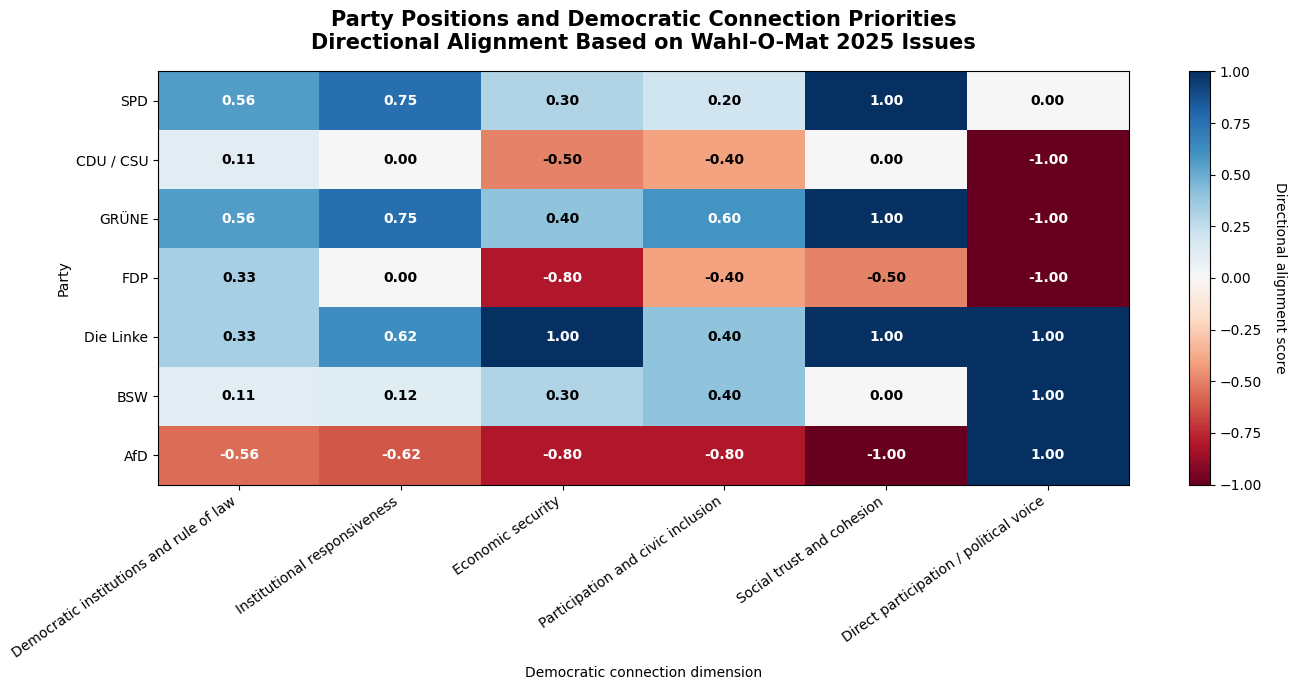

Heatmap saved to: ../data/processed/wahlomat_2025_party_alignment_heatmap.png


In [45]:
# 16. Visualize directional party-dimension alignment heatmap

import matplotlib.pyplot as plt
import numpy as np

heatmap_df = party_dimension_alignment_matrix.set_index("party_short").copy()

# Optional party order for readability
party_order = ["SPD", "CDU / CSU", "GRÜNE", "FDP", "Die Linke", "BSW", "AfD"]
heatmap_df = heatmap_df.loc[[p for p in party_order if p in heatmap_df.index]]

# Optional dimension order for storyline
dimension_order = [
    "Democratic institutions and rule of law",
    "Institutional responsiveness",
    "Economic security",
    "Participation and civic inclusion",
    "Social trust and cohesion",
    "Direct participation / political voice"
]

heatmap_df = heatmap_df[[col for col in dimension_order if col in heatmap_df.columns]]

fig, ax = plt.subplots(figsize=(14, 7))

im = ax.imshow(
    heatmap_df.values,
    cmap="RdBu",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_yticks(np.arange(len(heatmap_df.index)))

ax.set_xticklabels(heatmap_df.columns, rotation=35, ha="right")
ax.set_yticklabels(heatmap_df.index)

ax.set_title(
    "Party Positions and Democratic Connection Priorities\nDirectional Alignment Based on Wahl-O-Mat 2025 Issues",
    fontsize=15,
    weight="bold",
    pad=16
)

# Add cell labels
for i in range(len(heatmap_df.index)):
    for j in range(len(heatmap_df.columns)):
        value = heatmap_df.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="black" if abs(value) < 0.55 else "white",
            fontsize=10,
            weight="bold"
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Directional alignment score", rotation=270, labelpad=18)

ax.set_xlabel("Democratic connection dimension")
ax.set_ylabel("Party")

plt.tight_layout()

heatmap_path = DATA_PROCESSED / "wahlomat_2025_party_alignment_heatmap.png"
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")

plt.show()

print("Heatmap saved to:", heatmap_path)

## 16.1 Create Dark-Themed Alignment Heatmap

This step creates a dark-themed heatmap for visual consistency with the Streamlit app and final presentation.

The chart uses the same directional alignment scores as the previous heatmap, but applies a darker visual style.

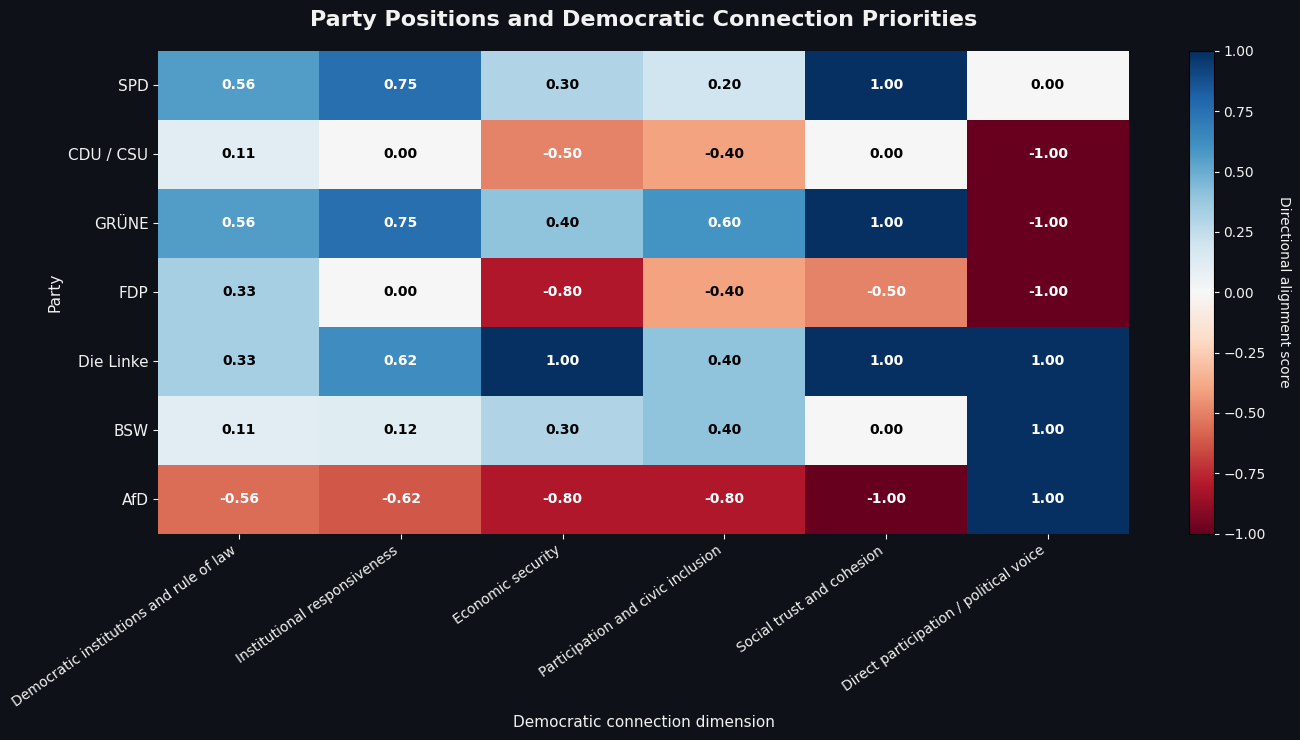

Dark heatmap saved to: ../data/processed/wahlomat_2025_party_alignment_heatmap_dark.png


In [46]:
# 16.1 Create dark-themed directional alignment heatmap

dark_bg = "#0E1117"
text_col = "#F2F2F2"
grid_col = "#333333"

fig, ax = plt.subplots(figsize=(14, 7.5))
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

im = ax.imshow(
    heatmap_df.values,
    cmap="RdBu",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_yticks(np.arange(len(heatmap_df.index)))

ax.set_xticklabels(
    heatmap_df.columns,
    rotation=35,
    ha="right",
    color=text_col,
    fontsize=10
)

ax.set_yticklabels(
    heatmap_df.index,
    color=text_col,
    fontsize=11
)

ax.set_title(
    "Party Positions and Democratic Connection Priorities",
    fontsize=16,
    weight="bold",
    color=text_col,
    pad=18
)

ax.set_xlabel(
    "Democratic connection dimension",
    color=text_col,
    fontsize=11
)

ax.set_ylabel(
    "Party",
    color=text_col,
    fontsize=11
)

ax.tick_params(colors=text_col)

# Add cell labels
for i in range(len(heatmap_df.index)):
    for j in range(len(heatmap_df.columns)):
        value = heatmap_df.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="black" if abs(value) < 0.45 else "white",
            fontsize=10,
            weight="bold"
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    "Directional alignment score",
    rotation=270,
    labelpad=18,
    color=text_col
)

cbar.ax.yaxis.set_tick_params(color=text_col)
plt.setp(cbar.ax.get_yticklabels(), color=text_col)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

dark_heatmap_path = DATA_PROCESSED / "wahlomat_2025_party_alignment_heatmap_dark.png"
plt.savefig(
    dark_heatmap_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print("Dark heatmap saved to:", dark_heatmap_path)

## 17. Check Evidence Strength by Democratic Connection Dimension

This step checks how many Wahl-O-Mat issues are mapped to each democratic connection dimension.

This is important because not all dimensions are equally well represented in the issue set.

A dimension based on many issues is more robust for interpretation than a dimension based on only one or two issues.

The evidence-strength classification is used to communicate this limitation transparently.

In [47]:
# 17. Check evidence strength by dimension

dimension_evidence_strength = (
    directional_relevant_positions
    .groupby("connection_dimension_label_refined")
    .agg(
        n_issues=("issue_id", "nunique"),
        n_party_positions=("position_score", "count")
    )
    .reset_index()
)

def classify_dimension_evidence(n_issues):
    if n_issues >= 6:
        return "stronger issue coverage"
    elif n_issues >= 3:
        return "moderate issue coverage"
    else:
        return "weak issue coverage"

dimension_evidence_strength["evidence_strength"] = (
    dimension_evidence_strength["n_issues"].apply(classify_dimension_evidence)
)

dimension_evidence_strength.sort_values("n_issues", ascending=False)

,connection_dimension_label_refined,n_issues,n_party_positions,evidence_strength
2,Economic security,10,70,stronger issue coverage
0,Democratic institutions and rule of law,9,63,stronger issue coverage
3,Institutional responsiveness,8,56,stronger issue coverage
4,Participation and civic inclusion,5,35,moderate issue coverage
5,Social trust and cohesion,2,14,weak issue coverage
1,Direct participation / political voice,1,7,weak issue coverage


## 17.1 Add Evidence Strength to Party-Dimension Summary

This step adds the dimension-level evidence strength classification to the party-dimension alignment summary.

This allows the final interpretation to distinguish between stronger and weaker issue coverage.

For example, direct participation / political voice is substantively important, but in this Wahl-O-Mat issue set it is based on only one issue. Therefore, it should be interpreted with caution.

In [48]:
# 17.1 Add evidence strength to party-dimension summary

party_dimension_alignment_summary = party_dimension_alignment_summary.merge(
    dimension_evidence_strength[
        [
            "connection_dimension_label_refined",
            "evidence_strength"
        ]
    ],
    on="connection_dimension_label_refined",
    how="left"
)

party_dimension_alignment_summary.sort_values(
    ["party_short", "connection_dimension_label_refined"]
)

,party_short,connection_dimension_label_refined,n_issues,mean_alignment_score,positive_alignment_count,neutral_alignment_count,negative_alignment_count,alignment_interpretation,evidence_strength
0,AfD,Democratic institutions and rule of law,9,-0.56,0,4,5,Visible negative alignment,stronger issue coverage
1,AfD,Direct participation / political voice,1,1.00,1,0,0,Visible positive alignment,weak issue coverage
2,AfD,Economic security,10,-0.80,0,2,8,Visible negative alignment,stronger issue coverage
3,AfD,Institutional responsiveness,8,-0.62,0,3,5,Visible negative alignment,stronger issue coverage
4,AfD,Participation and civic inclusion,5,-0.80,0,1,4,Visible negative alignment,moderate issue coverage
5,AfD,Social trust and cohesion,2,-1.00,0,0,2,Visible negative alignment,weak issue coverage
6,BSW,Democratic institutions and rule of law,9,0.11,2,6,1,Mixed or neutral alignment,stronger issue coverage
7,BSW,Direct participation / political voice,1,1.00,1,0,0,Visible positive alignment,weak issue coverage
8,BSW,Economic security,10,0.30,6,1,3,Mixed or neutral alignment,stronger issue coverage
9,BSW,Institutional responsiveness,8,0.12,3,3,2,Mixed or neutral alignment,stronger issue coverage


## 17.2 Export Updated Alignment Summary with Evidence Strength

This step exports the updated party-dimension alignment summary including evidence-strength information.

This is the preferred long-format file for Streamlit because it contains:

- party
- democratic connection dimension
- directional alignment score
- number of issues
- evidence-strength classification
- interpretation category

In [49]:
# 17.2 Export updated alignment summary with evidence strength

updated_directional_summary_path = (
    DATA_PROCESSED / "wahlomat_2025_party_democratic_connection_alignment_summary_with_evidence.csv"
)

dimension_evidence_path = (
    DATA_PROCESSED / "wahlomat_2025_dimension_evidence_strength.csv"
)

party_dimension_alignment_summary.to_csv(
    updated_directional_summary_path,
    index=False
)

dimension_evidence_strength.to_csv(
    dimension_evidence_path,
    index=False
)

print("Updated alignment summary exported to:", updated_directional_summary_path)
print("Dimension evidence strength exported to:", dimension_evidence_path)

Updated alignment summary exported to: ../data/processed/wahlomat_2025_party_democratic_connection_alignment_summary_with_evidence.csv
Dimension evidence strength exported to: ../data/processed/wahlomat_2025_dimension_evidence_strength.csv


## 18. Create App-Ready Party Alignment Files

This step creates final app-ready files for the exploratory party-position transfer layer.

The files are designed for Streamlit integration and contain:

- directional party-dimension alignment scores
- issue coverage strength
- cautious interpretation categories
- party-level summaries

This transfer layer is exploratory. It does not evaluate parties as democratic or undemocratic. It only maps standardized Wahl-O-Mat 2025 party positions to the democratic connection dimensions derived from the ESS analysis.

In [50]:
# 18. Create app-ready party alignment files

party_alignment_app = party_dimension_alignment_summary.copy()

party_alignment_app = party_alignment_app.rename(columns={
    "party_short": "party",
    "connection_dimension_label_refined": "democratic_connection_dimension",
    "mean_alignment_score": "alignment_score"
})

party_alignment_app = party_alignment_app[
    [
        "party",
        "democratic_connection_dimension",
        "n_issues",
        "alignment_score",
        "positive_alignment_count",
        "neutral_alignment_count",
        "negative_alignment_count",
        "alignment_interpretation",
        "evidence_strength"
    ]
].copy()

party_alignment_app.head()

,party,democratic_connection_dimension,n_issues,alignment_score,positive_alignment_count,neutral_alignment_count,negative_alignment_count,alignment_interpretation,evidence_strength
0,AfD,Democratic institutions and rule of law,9,-0.56,0,4,5,Visible negative alignment,stronger issue coverage
1,AfD,Direct participation / political voice,1,1.00,1,0,0,Visible positive alignment,weak issue coverage
2,AfD,Economic security,10,-0.80,0,2,8,Visible negative alignment,stronger issue coverage
3,AfD,Institutional responsiveness,8,-0.62,0,3,5,Visible negative alignment,stronger issue coverage
4,AfD,Participation and civic inclusion,5,-0.80,0,1,4,Visible negative alignment,moderate issue coverage


## 18.1 Create App-Ready Party Alignment Matrix

This step creates a wide-format party alignment matrix for heatmap visualizations in Streamlit.

Rows represent parties.
Columns represent democratic connection dimensions.
Values represent average directional alignment scores.

In [51]:
# 18.1 Create app-ready party alignment matrix

party_alignment_matrix_app = (
    party_alignment_app
    .pivot(
        index="party",
        columns="democratic_connection_dimension",
        values="alignment_score"
    )
    .reset_index()
)

party_alignment_matrix_app

democratic_connection_dimension,party,Democratic institutions and rule of law,Direct participation / political voice,Economic security,Institutional responsiveness,Participation and civic inclusion,Social trust and cohesion
0,AfD,-0.56,1.0,-0.8,-0.62,-0.8,-1.0
1,BSW,0.11,1.0,0.3,0.12,0.4,0.0
2,CDU / CSU,0.11,-1.0,-0.5,0.00,-0.4,0.0
3,Die Linke,0.33,1.0,1.0,0.62,0.4,1.0
4,FDP,0.33,-1.0,-0.8,0.00,-0.4,-0.5
5,GRÜNE,0.56,-1.0,0.4,0.75,0.6,1.0
6,SPD,0.56,0.0,0.3,0.75,0.2,1.0


## 18.2 Create Party-Level Summary

This step creates a party-level summary across all coded democratic connection dimensions.

The summary shows each party's average directional alignment score across the selected issue set.

This should be interpreted cautiously because the score depends on the Wahl-O-Mat issue selection and the manual dimension coding.

In [52]:
# 18.2 Create party-level summary

party_level_alignment_summary = (
    party_alignment_app
    .groupby("party")
    .agg(
        mean_alignment_score=("alignment_score", "mean"),
        n_dimensions=("democratic_connection_dimension", "nunique"),
        total_issues_covered=("n_issues", "sum"),
        positive_dimensions=("alignment_interpretation", lambda x: (x == "Visible positive alignment").sum()),
        mixed_dimensions=("alignment_interpretation", lambda x: (x == "Mixed or neutral alignment").sum()),
        negative_dimensions=("alignment_interpretation", lambda x: (x == "Visible negative alignment").sum())
    )
    .reset_index()
)

party_level_alignment_summary["mean_alignment_score"] = (
    party_level_alignment_summary["mean_alignment_score"].round(2)
)

party_level_alignment_summary = party_level_alignment_summary.sort_values(
    "mean_alignment_score",
    ascending=False
)

party_level_alignment_summary

,party,mean_alignment_score,n_dimensions,total_issues_covered,positive_dimensions,mixed_dimensions,negative_dimensions
3,Die Linke,0.72,6,35,5,1,0
6,SPD,0.47,6,35,3,3,0
5,GRÜNE,0.38,6,35,5,0,1
1,BSW,0.32,6,35,2,4,0
2,CDU / CSU,-0.30,6,35,0,3,3
4,FDP,-0.40,6,35,0,2,4
0,AfD,-0.46,6,35,1,0,5


## 18.3 Export App-Ready Party Alignment Files

This step exports the final party alignment files for Streamlit.

The preferred files for app integration are:

- app_party_alignment_long.csv
- app_party_alignment_matrix.csv
- app_party_alignment_party_summary.csv
- app_party_dimension_evidence_strength.csv

In [53]:
# 18.3 Export app-ready party alignment files

party_alignment_app.to_csv(
    DATA_APP / "app_party_alignment_long.csv",
    index=False
)

party_alignment_matrix_app.to_csv(
    DATA_APP / "app_party_alignment_matrix.csv",
    index=False
)

party_level_alignment_summary.to_csv(
    DATA_APP / "app_party_alignment_party_summary.csv",
    index=False
)

dimension_evidence_strength.to_csv(
    DATA_APP / "app_party_dimension_evidence_strength.csv",
    index=False
)

print("Exported app-ready party alignment files to:", DATA_APP)

Exported app-ready party alignment files to: ../data/app


## 19. Create Interactive Party Alignment Heatmap Preview

This step creates an interactive Plotly heatmap as a preview for the Streamlit app.

The heatmap shows directional alignment scores between party positions and democratic connection dimensions.

The color scale ranges from negative alignment to positive alignment.

This visualization should be interpreted as an exploratory transfer layer, not as a normative party ranking.

In [54]:
# 19. Create interactive party alignment heatmap preview

import plotly.express as px

heatmap_app_df = party_alignment_matrix_app.copy()

party_order = ["SPD", "CDU / CSU", "GRÜNE", "FDP", "Die Linke", "BSW", "AfD"]

dimension_order = [
    "Democratic institutions and rule of law",
    "Institutional responsiveness",
    "Economic security",
    "Participation and civic inclusion",
    "Social trust and cohesion",
    "Direct participation / political voice"
]

heatmap_app_df = heatmap_app_df.set_index("party")
heatmap_app_df = heatmap_app_df.loc[[p for p in party_order if p in heatmap_app_df.index]]
heatmap_app_df = heatmap_app_df[[d for d in dimension_order if d in heatmap_app_df.columns]]

fig = px.imshow(
    heatmap_app_df,
    text_auto=".2f",
    color_continuous_scale="RdBu",
    zmin=-1,
    zmax=1,
    aspect="auto",
    labels=dict(
        x="Democratic connection dimension",
        y="Party",
        color="Alignment score"
    ),
    title="Party Positions and Democratic Connection Priorities"
)

fig.update_layout(
    template="plotly_dark",
    height=600,
    paper_bgcolor="#0E1117",
    plot_bgcolor="#0E1117",
    font=dict(color="#F2F2F2"),
    title=dict(
        x=0.02,
        xanchor="left",
        font=dict(size=22)
    ),
    margin=dict(l=40, r=40, t=80, b=120)
)

fig.update_xaxes(tickangle=35)
fig.show()